# SHAP: Explaining an XGBoost model for Breast Cancer Diagnosis (Tabular Data)


In this tutorial, you will learn how to apply eXplainable methods to machine learning models for tabular data. The goal is to understand how the models operate and what are the main criterias used for the decision making. Since we are working with tabular data, we will consider a  very familiar use-case.

In particular, we are going to focus on a specific explanation model called SHapley Additive exPlanations, SHAP (https://arxiv.org/pdf/1705.07874.pdf). It will be implemented using the framework developed by Lundberg in https://github.com/slundberg/shap.

Based on game theory, SHAP considers each feature as a "player" in a cooperative game. In a nutshell, what SHAP does is quantifying the contribution that each feature brings to the prediction given by the model.

In this notebook we will learn how the SHAP values are computed mathematically with a simple example and then focus on a critical aplication of Machine Learning models: Breast Cancer Wisconsin Prediction.



### Shapley values: Definition

One of the main contribution of SHAP is to consider the explanation as a model itself. The explanation model is a linear function of a binary variable:


\begin{equation}
g(z') = \phi_0 + \sum_{i=1}^{M}\phi_i z'_i
\end{equation}

where $z' \in \{0,1\}^M $, M is the number of simplified features, and $\phi_i \; in \; \mathbb{R}$. *z'* represents the simplified features vector, $\phi_i $ is the feature attribution for feature *i*.

\begin{equation}
\phi_i = \sum_{S \subseteq F \ \{i\}} \frac{\mid S\mid! (\mid F\mid - \mid S\mid - 1)!}{\mid F\mid !} [f_{S \bigcup \{i\}}(x_{S \bigcup \{i\}}) - f_S(x_S)]
\end{equation}

where $f$ represents the model function, and $S \subseteq F $, where $F$ is the set of all features and $S$ a subset of $F$. Shap values are a weighted average of all possible difference subsets. $\mid S \mid$ represents the number of elements of subset $S$.

The Shapley value is a method that satisfies four properties: Efficiency, Symmetry, Dummy and Additivity.

Efficiency refers to the fact that the feature contribution must add up to the difference of the prediction for a given $x$ and the average.

The Symmetry property obligates the contributions of to feature values to be the same if they contribute identically to all possible coalitions.

Additivity: For bagging ensemble algorithms (i.e., bagging methods consist on fitting different models on the dataset and then average the outcome of each model), it means that the shap value can computed using the individual shap values for each independant model of the bagging algorithm.

Finally, the Dummy property is defined as the property of the shapley value that assures that the contribution of a feature that do not change the predicted value of the coalition of feature values that it has been added to
is equal to zero.

To be able to understand the Shap values, what they mean and how they are computed, we are going to consider a simple example: Let's imagine we have a model (any machine learning model) that outputs the  probability of not paying your credit given a set of 3 features (for instance age, localization and income).

SHAP values consider each combiniation or coalition of players (i.e., features) to determine the importance of a single player (i.e., features). As we are considering a simple set of 3 features, the number of different models with different sets of features we have to build are $2^3$. It is important to remark that all models are constructed with the same hyperparameters.



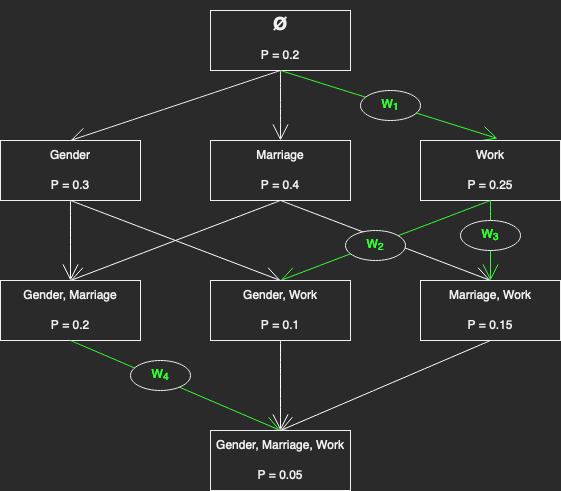

The output of the empty set ($\phi_0)$ is the number of total positive class cases over the number of data points. In this simple example the number of positive classes is 0.2. Now let's take a look on how the prediction of the model changes when we add the feature income for a single datapoint $x$. The considered set is the empty set.

$S_0 = \{\emptyset\}$

$f_{S_0}(x_{S_0}) = 0.2$

$f_{S_0 \bigcup \{work\}}(x_{S_0 \bigcup \{work\}}) = 0.25$

Now we consider all subsets of $F$ that that do not contain the feature *income*  ($S \subseteq F \ \{i\}$) and check the difference on the model's output when we consider the same subset, but adding the feature income.

$S_1 = \{gender\}$

$f_{S_1}(x_{S_1}) = 0.3$

$f_{S_1 \bigcup \{work\}}(x_{S_1 \bigcup \{work\}}) = 0.25$


$S_2 = \{Marriage\}$

$f_{S_2}(x_{S_2}) = 0.4$

$f_{S_2 \bigcup \{work\}}(x_{S_2 \bigcup \{work\}}) = 0.15$

$S_3 = \{Marriage, gender\}$

$f_{S_3}(x_{S_3}) = 0.2$

$f_{S_3 \bigcup \{work\}}(x_{S_3 \bigcup \{work\}}) = 0.05$

Once we find all model outputs for all different susbsets, we compute a weighted average of the model's output, with and without the feature.

The criteria the weights have to meet are the following:
  1. $\sum_{i} w_i = 1$
  2. $w_1 = w_2 + w_3 = w_4$

As mentioned above we are just considering the impact of the feature *income* in the model's outcome. To obtain the Shap values for the rest of the features we repeat the same strategy.

Let's apply the formula to obtain the Shap values $\phi_i$. Since we have four subsets that do not contain the feature *income*, we are going to feature attribution for each subset.

Feature attribution for $S_0$:

\begin{equation}
\frac{\mid S_0\mid! (\mid F\mid - \mid S_0\mid - 1)!}{\mid F\mid !} [f_{S_0 \bigcup \{i\}}(x_{S_0 \bigcup \{i\}}) - f_{S_0}(x_{S_0})] = \frac{0! (3 - 0 - 1)!}{3!} [0.25-0.2] = \frac{1}{3}0.05
\end{equation}

Now we repeat the same computation for $S_1$ , $S_2$, and $S_3$

For $S_1$: $\frac{1}{6}(-0.05)$

For $S_2$: $\frac{1}{6}(-0.25)$

For $S_3$: $\frac{1}{3}(-0.15)$

$\phi_i = \frac{1}{3}0.05 + \frac{1}{6}(-0.05) + \frac{1}{6}(-0.25) + \frac{1}{3}(-0.15) = -\frac{1}{6}0.5$

## Use Case: Breast Cancer Diagnosis Prediction (Tabular Data)

We study how SHAP values explain the predictions of a tree-based model (XGBoost) for a real medical dataset:
the Breast Cancer Wisconsin (Diagnostic) dataset.

**Goal**: predict whether a tumor is **malignant (1)** or **benign (0)** using features computed from digitized
images of a breast mass (mean radius, texture, concavity, etc.).

This is a good benchmark for explainability because:
- features are meaningful and continuous,
- the task is binary classification,
- tree-based models work well and are compatible with SHAP TreeExplainer.


### Setting the Environment

In [24]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn import model_selection, metrics
from sklearn.datasets import load_breast_cancer

from xgboost import XGBClassifier

In [25]:
data = load_breast_cancer(as_frame=True)

features = data["data"].copy()
target = data["target"].copy()  # 0 = malignant? (on va vérifier ci-dessous)

In [26]:
data.target_names

array(['malignant', 'benign'], dtype='<U9')

In [27]:
target.value_counts()

,count
target,
1,357
0,212


In [28]:
features.sample(n=3)

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,radius error,texture error,perimeter error,area error,smoothness error,compactness error,concavity error,concave points error,symmetry error,fractal dimension error,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
430,14.90,22.53,102.10,685.0,0.09947,0.22250,0.27330,0.09711,0.2041,0.06898,0.2530,0.8749,3.466,24.190,0.006965,0.062130,0.079260,0.022340,0.01499,0.005784,16.35,27.57,125.40,832.7,0.1419,0.7090,0.9019,0.24750,0.2866,0.11550
376,10.57,20.22,70.15,338.3,0.09073,0.16600,0.22800,0.05941,0.2188,0.08450,0.1115,1.2310,2.363,7.228,0.008499,0.076430,0.153500,0.029190,0.01617,0.012200,10.85,22.82,76.51,351.9,0.1143,0.3619,0.6030,0.14650,0.2597,0.12000
532,13.68,16.33,87.76,575.5,0.09277,0.07255,0.01752,0.01880,0.1631,0.06155,0.2047,0.4801,1.373,17.250,0.003828,0.007228,0.007078,0.005077,0.01054,0.001697,15.85,20.20,101.60,773.4,0.1264,0.1564,0.1206,0.08704,0.2806,0.07782


**Target Distribution**


**Target Distribution**

- Malignant: **0**
- Benign: **1**

(We verify this mapping from `data.target_names`.)

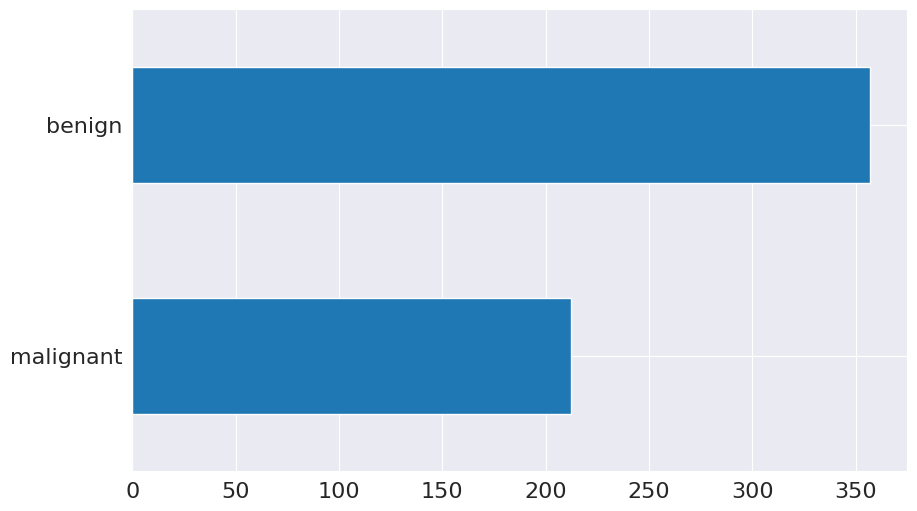

In [29]:
sns.set_style("darkgrid")
fig, ax = plt.subplots(figsize=(10,6))

counter = target.value_counts().sort_index()
# mapping via target_names: index 0 -> target_names[0], index 1 -> target_names[1]
counter.index = [data.target_names[i] for i in counter.index]

ax.set_xlabel("# Cases", size=14)
counter.plot(kind="barh", ax=ax)
plt.show()

In [30]:
x, y = features, target

In [31]:
x_train, x_test, y_train, y_test = model_selection.train_test_split(
    x,
    y,
    test_size=0.3,
    random_state=80,
    stratify=y
)

In [32]:
x_train

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,radius error,texture error,perimeter error,area error,smoothness error,compactness error,concavity error,concave points error,symmetry error,fractal dimension error,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
34,16.130,17.88,107.00,807.2,0.10400,0.15590,0.135400,0.077520,0.1998,0.06515,0.3340,0.6857,2.1830,35.030,0.004185,0.028680,0.026640,0.009067,0.017030,0.003817,20.210,27.26,132.70,1261.0,0.14460,0.58040,0.527400,0.186400,0.4270,0.12330
231,11.320,27.08,71.76,395.7,0.06883,0.03813,0.016330,0.003125,0.1869,0.05628,0.1210,0.8927,1.0590,8.605,0.003653,0.016470,0.016330,0.003125,0.015370,0.002052,12.080,33.75,79.82,452.3,0.09203,0.14320,0.108900,0.020830,0.2849,0.07087
88,12.360,21.80,79.78,466.1,0.08772,0.09445,0.060150,0.037450,0.1930,0.06404,0.2978,1.5020,2.2030,20.950,0.007112,0.024930,0.027030,0.012930,0.019580,0.004463,13.830,30.50,91.46,574.7,0.13040,0.24630,0.243400,0.120500,0.2972,0.09261
560,14.050,27.15,91.38,600.4,0.09929,0.11260,0.044620,0.043040,0.1537,0.06171,0.3645,1.4920,2.8880,29.840,0.007256,0.026780,0.020710,0.016260,0.020800,0.005304,15.300,33.17,100.20,706.7,0.12410,0.22640,0.132600,0.104800,0.2250,0.08321
192,9.720,18.22,60.73,288.1,0.06950,0.02344,0.000000,0.000000,0.1653,0.06447,0.3539,4.8850,2.2300,21.690,0.001713,0.006736,0.000000,0.000000,0.037990,0.001688,9.968,20.83,62.25,303.8,0.07117,0.02729,0.000000,0.000000,0.1909,0.06559
163,12.340,22.22,79.85,464.5,0.10120,0.10150,0.053700,0.028220,0.1551,0.06761,0.2949,1.6560,1.9550,21.550,0.011340,0.031750,0.031250,0.011350,0.018790,0.005348,13.580,28.68,87.36,553.0,0.14520,0.23380,0.168800,0.081940,0.2268,0.09082
71,8.888,14.64,58.79,244.0,0.09783,0.15310,0.086060,0.028720,0.1902,0.08980,0.5262,0.8522,3.1680,25.440,0.017210,0.093680,0.056710,0.017660,0.025410,0.021930,9.733,15.67,62.56,284.4,0.12070,0.24360,0.143400,0.047860,0.2254,0.10840
174,10.660,15.15,67.49,349.6,0.08792,0.04302,0.000000,0.000000,0.1928,0.05975,0.3309,1.9250,2.1550,21.980,0.008713,0.010170,0.000000,0.000000,0.032650,0.001002,11.540,19.20,73.20,408.3,0.10760,0.06791,0.000000,0.000000,0.2710,0.06164
188,11.810,17.39,75.27,428.9,0.10070,0.05562,0.023530,0.015530,0.1718,0.05780,0.1859,1.9260,1.0110,14.470,0.007831,0.008776,0.015560,0.006240,0.031390,0.001988,12.570,26.48,79.57,489.5,0.13560,0.10000,0.088030,0.043060,0.3200,0.06576
205,15.120,16.68,98.78,716.6,0.08876,0.09588,0.075500,0.040790,0.1594,0.05986,0.2711,0.3621,1.9740,26.440,0.005472,0.019190,0.020390,0.008260,0.015230,0.002881,17.770,20.24,117.70,989.5,0.14910,0.33310,0.332700,0.125200,0.3415,0.09740


In [33]:
counter = y_train.value_counts()
# scale_pos_weight = (negatives / positives) where "positive" is class 1
scale_pos_weight = counter[0] / counter[1]

params_xgb = {
    "n_estimators": 300,
    "max_depth": 4,
    "learning_rate": 0.05,
    "subsample": 0.9,
    "colsample_bytree": 0.9,
    "scale_pos_weight": scale_pos_weight,
    "random_state": 80
}

xgb = XGBClassifier(**params_xgb, eval_metric="logloss")
xgb.fit(x_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.9, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=4, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=None,
              num_parallel_tree=None, ...)

Text(0.5, 1.0, 'Confusion Matrix (Train set)')

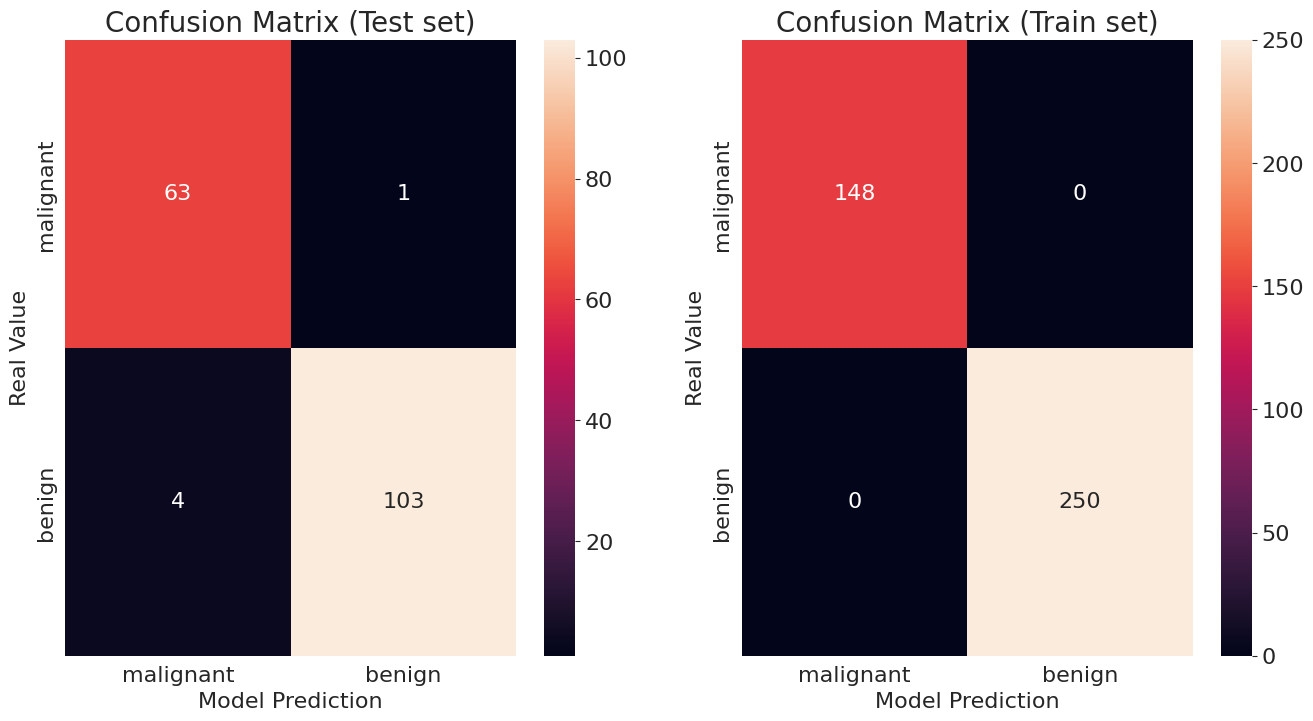

In [35]:
y_hat = xgb.predict(x_test)
cf = metrics.confusion_matrix(y_pred=y_hat, y_true=y_test)
cf_train = metrics.confusion_matrix(y_pred=xgb.predict(x_train), y_true=y_train)
names_df = [data.target_names[0], data.target_names[1]]

cf_df = pd.DataFrame(data=cf, columns=names_df, index=names_df)
cf_train_df = pd.DataFrame(data=cf_train, columns=names_df, index=names_df)
fig, ax = plt.subplots(ncols=2, figsize=(16,8))

sns.heatmap(cf_df, fmt="d",annot=True, ax=ax[0])
ax[0].set_xlabel("Model Prediction", size=16)
ax[0].set_ylabel("Real Value", size=16)
ax[0].set_title("Confusion Matrix (Test set)", size=20)

sns.heatmap(cf_train_df, fmt="d",annot=True, ax=ax[1])
ax[1].set_xlabel("Model Prediction", size=16)
ax[1].set_ylabel("Real Value", size=16)
ax[1].set_title("Confusion Matrix (Train set)", size=20)

## SHAP Values

**After validating the predictive performance of the model, we now focus on explaining its predictions using SHAP.** We use the framework developed by Lundberg et al. https://github.com/slundberg/shap

In [36]:
#Run if shap not installed
! pip install shap

In [37]:
import shap

**We are going to explain the xgboost model. Since the model developed previously is a tree based we are going to use Tree explainer, a fast implementation to compute Shap values when models are tree based**

In [45]:
explainer = shap.TreeExplainer(xgb, x_train, model_output="raw")
shap_values = explainer.shap_values(x_test)

**Local interpretability: How do we interpret the SHAP force plot?**


The value we observe in bold is the natural logarithm of the odd ratio $ln(\frac{P(Y=1)}{1-P(Y=1)})$. The base value is the odd ratio if we just consider the number of positive cases over the total of instances. The Shapley values can be understood as forces that push the output of the model. Forces of Shapley values in blue represent the features that increase the probability of default, while red values represent the features that are incrementing the probability of having a malignant tumor / benign tumor.

A force plot allows us to study a concrete case in order to give a reason for diagnosing a potential malignant tumor / benign tumor.

In [50]:
shap.initjs()
sample_index = 2
shap.force_plot(explainer.expected_value, shap_values[sample_index, :], x_test.iloc[sample_index, :])

**1.** La majorité des features (en bleu) poussent fortement la prédiction vers la classe bénigne

**2.** Les variables les plus influentes sont :

- worst perimeter

- worst area

- worst texture

- worst concavity

- mean concave points

Ces variables ont ici des valeurs faibles, ce qui est typique des tumeurs bénignes

**3.** Les contributions positives (rouges) sont faibles et insuffisantes pour inverser la décision

**From a medical perspective, malignant tumors tend to have larger perimeter, higher concavity and more irregular shapes. The model therefore relies on clinically meaningful features, which increases trust in its predictions.**

In [47]:
y_hat = xgb.predict(x_test)
print("Accuracy:", metrics.accuracy_score(y_test, y_hat))
print(metrics.classification_report(y_test, y_hat, target_names=data.target_names))

Accuracy: 0.9707602339181286
              precision    recall  f1-score   support

   malignant       0.94      0.98      0.96        64
      benign       0.99      0.96      0.98       107

    accuracy                           0.97       171
   macro avg       0.97      0.97      0.97       171
weighted avg       0.97      0.97      0.97       171



In [53]:
sample_index = 5  # index dans x_test / y_test

class_map = {0: data.target_names[0], 1: data.target_names[1]}  # ex: 0->malignant, 1->benign

print("------- True label (test sample) ------")
true_class = int(y_test.iloc[sample_index])
print(class_map[true_class])

print("------- Predicted label (test sample) ------")
proba = xgb.predict_proba(x_test.iloc[[sample_index]])[0]
pred_class = int(np.argmax(proba))
print(class_map[pred_class])

print("------- Predicted probabilities ------")
for k, name in class_map.items():
    print(f"P({name}) = {proba[k]:.3f}")

------- True label (test sample) ------
benign
------- Predicted label (test sample) ------
benign
------- Predicted probabilities ------
P(malignant) = 0.087
P(benign) = 0.913


The SHAP force plot provides a local explanation for a single test sample classified as **benign** with very high confidence (*P = 0.999*).

**The model output is expressed in log-odds space. The base value represents the average model output over the training data, while individual feature contributions (SHAP values) push the prediction either towards the benign or malignant class.**

**Global interpretability: SHAP Summary plot.**

The SHAP summary plot allows us to understand the model by ranking the features from the most relevant to the least important ones. Each datapoint represents a different person. In this concrete use case, the most relevant feature are: the variation of the activity mesasurements obtained of the actigraph watch, the Montgomery Asberg Depression Rating Scale at the moment the actigraph was stopped. High values of these features impact negatively in the output of the model **(the probability of having a malignant tumor increases)**.

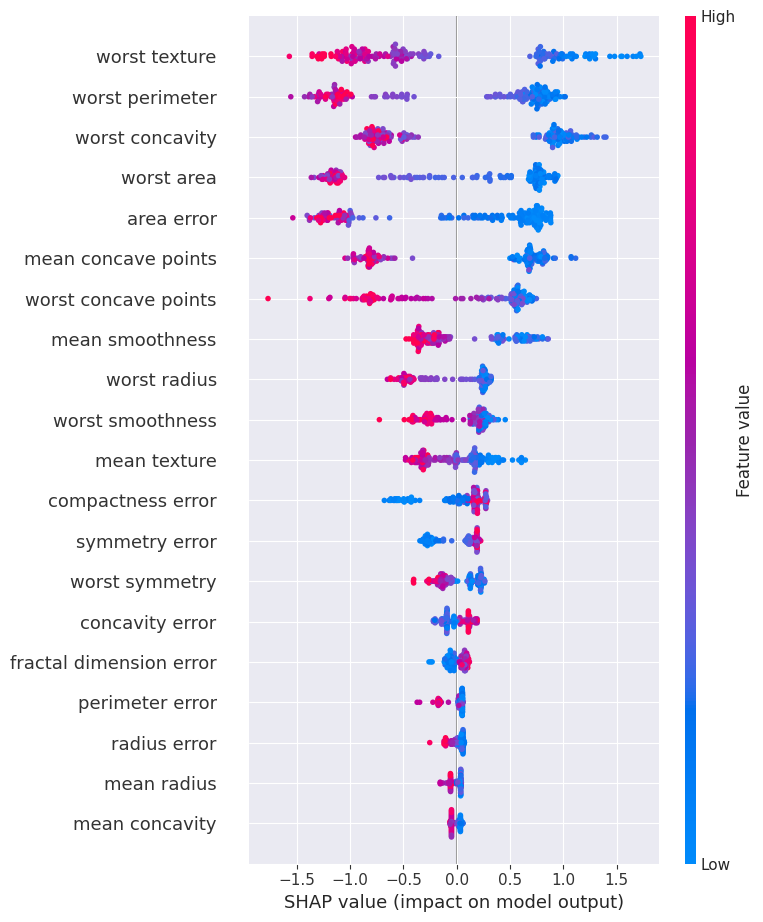

<Figure size 640x480 with 0 Axes>

In [51]:
shap.summary_plot(shap_values, x_test)

plt.savefig("shap_summary_plot.png", bbox_inches="tight")

**The SHAP summary plot highlights the most influential features across the entire test set.**

**Features related to tumor size and shape (worst texture, worst perimeter, worst concavity, worst area) dominate the model’s decision process.**

*This plot shows that the model behaves in a monotonic and clinically coherent manner: higher values of size and concavity-related features consistently increase malignancy risk.*

### **Strengths of SHAP**

**1. Local interpretability of individual predictions**

  SHAP provides precise explanations for individual predictions by quantifying the contribution of each feature to a specific model output, allowing detailed case-by-case analysis.

**2. Global understanding of model behavior**

  By aggregating local explanations, SHAP enables a global interpretation of the model, highlighting the most influential features across the entire dataset.

**3. Theoretical foundation and consistency**

  SHAP is grounded in cooperative game theory and satisfies desirable properties such as additivity and consistency, ensuring reliable and principled explanations.

**4. Model-agnostic framework with efficient implementations**

  While the SHAP framework is model-agnostic, optimized implementations (e.g., TreeExplainer) allow efficient computation for tree-based models without sacrificing accuracy.

**5. Alignment with domain knowledge**

  SHAP explanations often reflect meaningful relationships between features and predictions, which facilitates validation by domain experts and increases trust in the model.

### **Limitations of SHAP**

**1. Sensitivity to feature correlation**

  When input features are strongly correlated (e.g., radius, perimeter, area), SHAP may distribute importance arbitrarily among them, making individual attributions harder to interpret.

**2. Model-dependent explanations**

  SHAP explains the behavior of a specific trained model, not the underlying data-generating process. Different models or hyperparameters may lead to different explanations.

**3. Lack of causal interpretation**

  High SHAP values indicate feature influence on the prediction, but do not imply causal relationships. A feature may be important without being a true cause of the outcome.

**4. Dependence on background data**

  The choice of the background dataset (e.g., training data) directly affects SHAP values, which may introduce variability in explanations.

**5. Interpretation complexity for non-technical users**

  SHAP values expressed in log-odds or additive contributions can be difficult to interpret for non-expert stakeholders, especially in high-stakes domains such as healthcare.

### **In conclusion, SHAP provides meaningful insights into both individual predictions and global model behavior. While these explanations improve transparency and trust, they remain model-dependent and should be interpreted with caution in real-world medical decision-making.**